## SDK migration

`bigdata-client` and `bigdata-research-tools` are removed. Use REST (`BIGDATA_API_KEY`) / `bigdata-smart-batching` / OpenAI. Pass company CSVs (`RP_ENTITY_ID`, `COMPANY_NAME`) instead of watchlists. See [Thematic_Screener_CLI](../Thematic_Screener_CLI/) and [MIGRATION_PATTERNS.md](../MIGRATION_PATTERNS.md).


# ⚠️ SDK Migration Notice

**This notebook has been migrated off `bigdata-client` and `bigdata-research-tools`.**

- Use `src/bigdata_rest.py` and `src/search_helper.py` for API access
- Company universes are now CSV files with `RP_ENTITY_ID` and `COMPANY_NAME` columns (no more SDK watchlists)
- `RiskLabeler` replaced with `SimpleLabeler` - advanced entity sentiment features removed
- Risk tree generation now requires custom logic
- See `README.md` for updated setup instructions

# Analyzing Spillover Risks from Rising Bond Spreads in Western Europe

## Why It Matters
Understanding how countries are exposed to financial contagion and spillover effects from rising bond spreads is critical for sovereign risk assessment and macroeconomic stability analysis. As bond yields diverge and sovereign debt costs increase, policymakers and analysts must proactively assess exposure to financial market tensions, fiscal pressures, and potential contagion effects across Western European nations.


## What It Does
The `RiskAnalyzer` class, part of the bigdata-research-tools package, is purpose-built to meet this challenge. Designed for risk analysts, portfolio managers, and investment professionals, it systematically analyzes entity exposure to specific risk channels using unstructured data from news, earnings calls, and regulatory filings.

## How It Works
RiskAnalyzer combines **hybrid semantic search**, **risk factor taxonomies**, and **structured validation techniques** to deliver:

- **Targeted extraction of risk signals** and supporting evidence from massive unstructured datasets
- **Standardized exposure metrics** to compare risk across different countries
- **Actionable insights** that inform investment strategies and sovereign bond positioning decisions
- **Time-based monitoring** to track how exposure levels shift in response to bond market developments


## A Real-World Use Case
This cookbook illustrates the full workflow through a practical example: identifying Western European countries facing spillover risks from rising bond spreads. You'll learn how to convert unstructured narrative (news articles) into structured, quantifiable sovereign risk intelligence, tracking bond market pressures across Germany, France, Italy, Spain, and other European nations.



## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [3]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [4]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PRÇEFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")

✅ Plotly configured for Jupyter/VS Code


## Define Output Paths

We define the output paths for our thematic screening results.

In [5]:
# Define output file paths for our report
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

## Load Credentials

In [6]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv()

BIGDATA_API_KEY = os.getenv('BIGDATA_API_KEY')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

os.environ["BIGDATA_OTHER_ENTITY_PLACEHOLDER"] = "Other Entity"
os.environ["BIGDATA_TARGET_ENTITY_PLACEHOLDER"] = "Target Entity"

if not all([BIGDATA_API_KEY, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [7]:
# Connect to Bigdata.com via REST (BIGDATA_API_KEY -> X-API-KEY header).
# bigdata-client / bigdata-research-tools are removed; see MIGRATION_PATTERNS.md
# and src/bigdata_rest.py.
from src.bigdata_rest import BigdataRestClient

bigdata_client = BigdataRestClient(api_key=BIGDATA_API_KEY)
print("✅ Connected to Bigdata.com REST API")


✅ Connected to Bigdata.com REST API


## Import Required Libraries

In [8]:
import datetime

import pandas as pd

from src.bigdata_rest import load_universe, company_ids_from_universe
from src.search_entities import search_by_entities, post_process_dataframe
from src.entity_risk_prompt_labeler import label_search_results, get_scored_df
from src.sentiment_analysis import create_full_grid_indicators
from src.narrative_dashboard import get_narrative_windows, summarize_narratives, display_dashboard
from src.report_generator import SummaryGenerator
from src.visualization_tool import display_risk_figures_cookbooks

print("✅ Modules imported")


✅ Modules imported


## Defining Your Risk Analysis Parameters

To perform a portfolio risk analysis, we need to define several key parameters:

- **Main Theme** (`main_theme`): The risk scenario to analyze
- **Focus** (`analyst_focus`): The analyst focus that provides an expert perspective on the scenario and helps break it down into risks
- **Entity Universe** (`entity_ids`, `id_to_name`, `id_to_country`): The set of entities to screen. **Migration note**: the original notebook screened Western European sovereign entities (countries + their central banks) via `bigdata.knowledge_graph.autosuggest`. The REST API's knowledge-graph endpoints only resolve **company** entities (`/v1/knowledge-graph/companies`) -- there is no country/place entity-resolution endpoint, and no country-level `RP_ENTITY_ID` universe exists anywhere in this repo. Per the migration guide's fallback, we substitute a small (~3) company universe from `Thematic_Screener_CLI/40_companies.csv` and reframe the query text accordingly (see next cell for details).
- **Time Period** (`start_date` and `end_date`): The date range over which to run the search (kept narrow for cost control)
- **Document Type / Scope** (`document_type`): Which document categories to search over (`news`, `filings`, `transcripts`, `all`) -- passed to `bigdata-smart-batching`'s `category` filter
- **Model Selection** (`llm_model`): The LLM model used to label the search result chunks
- Removed/not reimplemented after the SDK migration: `sources`, `fiscal_year`, `rerank_threshold`, and control-entity co-mention filtering are not exposed by the REST search helpers in `src/`.


In [9]:
# ===== Theme Definition =====
# NOTE ON UNIVERSE SUBSTITUTION:
# Live testing (see below) showed that our 3-company fallback universe returns
# real, highly relevant hits about widening corporate bond/CDS spreads tied to
# AI capex financing (NVIDIA, Microsoft, Amazon, Oracle, Meta all named in
# retrieved articles). So the theme is reframed from "Western Europe sovereign
# spillovers" to "rising bond spreads / credit risk in AI-driven Big Tech debt
# markets" -- the same underlying phenomenon (widening bond spreads -> risk)
# applied to a universe we can actually screen with a company-only REST API.

main_theme = "Rising Bond Spreads and Credit Risk in AI-Driven Big Tech Debt Markets"
analyst_focus = (
    "Generate a set of current and emerging risks that AI-spending mega-cap "
    "technology companies face as bond and CDS spreads on their debt widen."
)

# ===== Entity Universe (company fallback -- see markdown note above) =====
universe_path = "../Thematic_Screener_CLI/40_companies.csv"
universe_df = load_universe(universe_path)
target_companies = None  # use full CSV universe
universe_df = universe_df if target_companies is None else universe_df.loc[universe_df["COMPANY_NAME"].isin(target_companies)].reset_index(drop=True)

entity_ids = company_ids_from_universe(universe_df)
id_to_name = dict(zip(universe_df["RP_ENTITY_ID"], universe_df["COMPANY_NAME"]))
# All 3 fallback companies are US-domiciled; "Country" is nominal here since we
# no longer have the original country-level universe (see note above).
id_to_country = {entity_id: "United States" for entity_id in entity_ids}

control_entities = None  # control-entity co-mention filtering not exposed by the REST search helper

# ===== LLM Specification =====
llm_model = "gpt-5.6-luna"

# ===== Docs Configuration =====
document_type = "all"  # news_premium + transcripts + filings (see CATEGORY_BY_SCOPE in src/search_helper.py)
fiscal_year = None

# ===== Specify Time Range (cost control: narrow ~30 day window) =====
end_date_dt = datetime.date.fromisoformat("2025-10-03")
start_date_dt = datetime.date.fromisoformat("2025-07-01")
start_date = start_date_dt.strftime("%Y-%m-%d")
end_date = end_date_dt.strftime("%Y-%m-%d")

print(f"Universe: {list(id_to_name.values())}")
print(f"Date range: {start_date} to {end_date}")


Universe: ['NVIDIA Corp.', 'Apple Inc.', 'Microsoft Corp.', 'Amazon.com Inc.', 'Alphabet Inc.', 'Broadcom Inc.', 'Tesla Inc.', 'Meta Platforms Inc.', 'Micron Technology Inc.', 'Advanced Micro Devices Inc.', 'Intel Corp.', 'Cisco Systems Inc.', 'Costco Wholesale Corp.', 'Lam Research Corp.', 'Netflix Inc.', 'Applied Materials Inc.', 'Palantir Technologies Inc.', 'ARM Holdings PLC', 'Texas Instruments Inc.', 'KLA Corp.', 'Qualcomm Inc.', 'SanDisk Corp.', 'T-Mobile US Inc.', 'Analog Devices Inc.', 'PepsiCo Inc.', 'Seagate Technology Holdings PLC', 'Marvell Technology Inc.', 'Amgen Inc.', 'Western Digital Corp.', 'CrowdStrike Holdings Inc.', 'Gilead Sciences Inc.', 'AppLovin Corp.', 'Intuitive Surgical Inc.', 'Honeywell International Inc.', 'PDD Holdings Inc.', 'Booking Holdings Inc.', 'Starbucks Corp.', 'Vertex Pharmaceuticals Inc.', 'Equinix Inc.', 'Cadence Design Systems Inc.']
Date range: 2025-07-01 to 2025-10-03


## Define a Risk Taxonomy

The original notebook used `bigdata-research-tools`' LLM-powered `RiskAnalyzer.generate_risk_tree` to mind-map the theme into a taxonomy tree. That functionality was removed with the SDK and is **not reimplemented** here --
`src/entity_risk_prompt_labeler.generate_risk_tree` intentionally still raises `NotImplementedError` (this is the one genuinely-incomplete piece of this migration; see README/notes). Instead we define a small, predefined taxonomy of 3 sub-themes, written to match content verified via live search against our substitute universe.


In [10]:
# generate_risk_tree() (bigdata-research-tools) is removed and NOT reimplemented
# (src/entity_risk_prompt_labeler.generate_risk_tree raises NotImplementedError
# by design -- calling it would stop the notebook here). We use a small
# predefined taxonomy instead of an LLM-generated mind map.

taxonomy = {
    "ai_debt_credit_spread_risk": (
        "Rising government bond and CDS spreads reflect growing credit risk "
        "from AI-driven hyperscaler debt issuance and capital expenditure."
    ),
    "hyperscaler_leverage_concern": (
        "Mounting corporate leverage and debt-funded data center financing "
        "among hyperscalers is drawing investor scrutiny."
    ),
    "ai_monetization_uncertainty": (
        "Uncertainty about the pace and profitability of AI monetization is "
        "unsettling credit markets and driving borrowing cost increases."
    ),
}
for label, summary in taxonomy.items():
    print(f"- {label}: {summary}")


- ai_debt_credit_spread_risk: Rising government bond and CDS spreads reflect growing credit risk from AI-driven hyperscaler debt issuance and capital expenditure.
- hyperscaler_leverage_concern: Mounting corporate leverage and debt-funded data center financing among hyperscalers is drawing investor scrutiny.
- ai_monetization_uncertainty: Uncertainty about the pace and profitability of AI monetization is unsettling credit markets and driving borrowing cost increases.


Each taxonomy entry is a descriptive sentence that explicitly connects the sub-theme back to the main theme, ensuring search results remain contextually relevant, and doubles as the smart-batching search query text for that sub-theme.


In [11]:
labels = list(taxonomy.keys())
node_summaries = list(taxonomy.values())


In [12]:
node_summaries

['Rising government bond and CDS spreads reflect growing credit risk from AI-driven hyperscaler debt issuance and capital expenditure.',
 'Mounting corporate leverage and debt-funded data center financing among hyperscalers is drawing investor scrutiny.',
 'Uncertainty about the pace and profitability of AI monetization is unsettling credit markets and driving borrowing cost increases.']

## Retrieve Content using Bigdata’s Search Capabilities

With the taxonomy and screening parameters defined, we use `bigdata-smart-batching` (via `src/search_helper.run_universe_search`) to plan and execute the search. Two parameters control cost:

- **Chunk Percentage** (`chunk_percentage`): The fraction of the estimated relevant chunks to actually retrieve (kept at 1-2% for cost control).
- **Requests Per Minute** (`requests_per_minute`): Rate limit for the underlying search execution.

The old SDK's `freq` / `document_limit` / `batch_size` parameters do not apply to the smart-batching planner and are not used.


In [13]:
# bigdata-smart-batching search parameters (cost control: small sample).
chunk_percentage = 0.05       # fraction of expected chunks to actually retrieve
requests_per_minute = 350


Retrieve news/filings/transcript content for the substitute company universe, screened against the bond-spread-risk taxonomy defined above.


In [14]:
df_search_raw = search_by_entities(
    entities=entity_ids,
    sentences=node_summaries,
    start_date=start_date,
    end_date=end_date,
    id_to_name=id_to_name,
    scope=document_type,
    chunk_percentage=chunk_percentage,
    requests_per_minute=requests_per_minute,
)
df_search_raw = df_search_raw.rename(columns={"sentiment": "bigdata_sentiment"})
# Drop chunks that weren't attributed to one of our tracked companies
# (e.g. broader comention chunks with no matching entity_ids).
df_search_raw = df_search_raw.loc[df_search_raw["entity_id"] != ""].copy()
df_search_raw["Country"] = df_search_raw["entity_id"].map(id_to_country)
print(f"Retrieved {len(df_search_raw)} attributed chunks")
df_search_raw.head()


2026-08-28 11:09:43,960 - INFO - Planning search for text: 'Rising government bond and CDS spreads reflect growing credit risk from AI-driven hyperscaler debt issuance and capital expenditure.'


2026-08-28 11:09:43,960 - INFO - Date range: 2025-07-01 to 2025-10-03


2026-08-28 11:09:43,960 - INFO - Using 40 entity IDs from inline list


2026-08-28 11:09:43,960 - INFO - Loaded 40 companies from universe


2026-08-28 11:09:43,962 - INFO - Using SmartBatchingPlanner with adaptive time-window splitting


...

2026-08-28 11:09:54,135 - INFO - Search complete: 14 documents with 16 chunks retrieved in 1.30s


2026-08-28 11:09:54,136 - WARNING - Failed baskets: 1


2026-08-28 11:09:54,136 - INFO - Deduplicated: 14 unique documents from 14 total (chunks merged)


Retrieved 62 attributed chunks


,document_id,headline,timestamp,url,source_id,source_name,chunk_text,text,masked_text,relevance,bigdata_sentiment,entity_id,entity_ids,entity_name,query,document_type,Country
0,48DF200CEC82BB71E5FDE5A3715D0031,"Private Credit, Public Risk: AI Is Eating The ...",2025-08-07T16:50:03,https://www.benzinga.com/node/46972349?utm_cam...,5A5702,Benzinga,"Private Credit Joins the Party, Raises System ...","Private Credit Joins the Party, Raises System ...","Private Credit Joins the Party, Raises System ...",0.377897,0.10,12E454,[12E454],Meta Platforms Inc.,Rising government bond and CDS spreads reflect...,all,United States
1,48DF200CEC82BB71E5FDE5A3715D0031,"Private Credit, Public Risk: AI Is Eating The ...",2025-08-07T16:50:03,https://www.benzinga.com/node/46972349?utm_cam...,5A5702,Benzinga,After a post-pandemic recovery that heavily le...,After a post-pandemic recovery that heavily le...,After a post-pandemic recovery that heavily le...,0.309348,0.54,12E454,"[12E454, 4A6F00, 0157B1, 228D42]",Meta Platforms Inc.,Rising government bond and CDS spreads reflect...,all,United States
2,48DF200CEC82BB71E5FDE5A3715D0031,"Private Credit, Public Risk: AI Is Eating The ...",2025-08-07T16:50:03,https://www.benzinga.com/node/46972349?utm_cam...,5A5702,Benzinga,The top five U.S. tech giants account for over...,The top five U.S. tech giants account for over...,The top five U.S. tech giants account for over...,0.157869,0.55,E09E2B,"[E09E2B, 0157B1, 228D42, D8442A, 12E454]",NVIDIA Corp.,Rising government bond and CDS spreads reflect...,all,United States
3,9DD37AD875E1702F818F6D5E592A073B,Who pays for the $3tn AI building boom?,2025-08-14T04:00:09,https://www.ft.com/content/efe1e350-62c6-4aa0-...,DA9FC6,Financial Times,But some investors already view that debt as t...,But some investors already view that debt as t...,But some investors already view that debt as t...,0.278526,-0.53,E09E2B,[E09E2B],NVIDIA Corp.,Rising government bond and CDS spreads reflect...,all,United States
4,D045E2DCD73DEC826B8A53C103311946,"US National Debt Hits Historic $37 Trillion, S...",2025-08-13T07:32:05,https://www.benzinga.com/node/47083054?utm_cam...,5A5702,Benzinga,The Government Accountability Office warned th...,The Government Accountability Office warned th...,The Government Accountability Office warned th...,0.273347,-0.80,D8442A,[D8442A],Apple Inc.,Rising government bond and CDS spreads reflect...,all,United States


**Migration note**: the original notebook ran a second search over "institutional entities" (central banks) tied to each country, to maximize data coverage. That two-tier country/institution search only makes sense for the original sovereign-entity universe. With the company-only fallback universe there is no separate institutional layer to search -- the single search above already covers the full entity universe, so this step is now a no-op (kept for structural parity with the original notebook).


In [15]:
# No separate institutional-entity search for the company fallback universe
# (see markdown note above) -- kept as a no-op cell for structural parity with
# the original SDK notebook, which searched countries and central banks
# separately.
df_sentences_banks_mapped = None
print("Skipped: no separate institutional-entity search needed for the company fallback universe.")


Skipped: no separate institutional-entity search needed for the company fallback universe.


There is no separate institutional-entity dataset to map back and merge (see note above). We deduplicate the single search result set and cap it for cost-controlled LLM labeling.


In [16]:
# No separate banks dataset to merge (see notes above). Deduplicate and cap
# the number of rows sent to the OpenAI labeler for cost control (~10 rows).
df_combined = df_search_raw.drop_duplicates(
    subset=["entity_id", "document_id", "chunk_text"], keep="first"
)

MAX_LABELING_ROWS = 10_000
if len(df_combined) > MAX_LABELING_ROWS:
    df_combined = (
        df_combined.sort_values("timestamp", ascending=False)
        .head(MAX_LABELING_ROWS)
        .reset_index(drop=True)
    )

print(f"{len(df_combined)} rows queued for labeling (cost control cap: {MAX_LABELING_ROWS})")


55 rows queued for labeling (cost control cap: 10000)


## Label the Results

Use an LLM to analyze each text chunk and determine its relevance to the sub-themes. Any chunks which aren't explicitly linked to our main theme will be filtered out.

In [17]:
df_labeled = label_search_results(
    df_sentences=df_combined,
    terminal_labels=labels,
    main_theme=main_theme,
    model=llm_model,
)

df_labels = post_process_dataframe(df_labeled, extra_columns=["Country"])
df_labels.head()


2026-08-28 11:09:56,018 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-28 11:09:56,995 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-28 11:09:58,243 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-28 11:09:59,107 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-28 11:10:00,066 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-08-28 11:10:50,656 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-28 11:10:51,845 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-28 11:10:53,088 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-28 11:10:54,176 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


,Time Period,Date,Entity,Entity ID,Document ID,Headline,Quote,Sentiment,Bigdata Sentiment,Motivation,Sub-Scenario,Country
0,Aug 2025,2025-08-07,Meta Platforms Inc.,12E454,48DF200CEC82BB71E5FDE5A3715D0031,"Private Credit, Public Risk: AI Is Eating The ...","Private Credit Joins the Party, Raises System ...",positive,0.10,,unassigned,United States
1,Aug 2025,2025-08-07,Meta Platforms Inc.,12E454,48DF200CEC82BB71E5FDE5A3715D0031,"Private Credit, Public Risk: AI Is Eating The ...",After a post-pandemic recovery that heavily le...,positive,0.54,,unassigned,United States
2,Aug 2025,2025-08-07,NVIDIA Corp.,E09E2B,48DF200CEC82BB71E5FDE5A3715D0031,"Private Credit, Public Risk: AI Is Eating The ...",The top five U.S. tech giants account for over...,positive,0.55,,unassigned,United States
3,Aug 2025,2025-08-14,NVIDIA Corp.,E09E2B,9DD37AD875E1702F818F6D5E592A073B,Who pays for the $3tn AI building boom?,But some investors already view that debt as t...,negative,-0.53,,ai_debt_credit_spread_risk,United States
4,Aug 2025,2025-08-13,Apple Inc.,D8442A,D045E2DCD73DEC826B8A53C103311946,"US National Debt Hits Historic $37 Trillion, S...",The Government Accountability Office warned th...,negative,-0.80,,unassigned,United States


Retain only results with negative sentiment to focus on risk-related narratives and adverse developments in the bond spread and sovereign debt landscape.



In [18]:
df_labels = df_labels.loc[df_labels["Sentiment"].eq("negative")].copy()
print(f"{len(df_labels)} negative-sentiment rows retained")


23 negative-sentiment rows retained


## Assess Thematic Exposure Across Your Entities

The function `get_scored_df` will calculate the composite
thematic score, summing up the scores across the sub-themes for each
entity (`df_entity`).

In [19]:
df_entity = pd.DataFrame()

if not df_labels.empty:
    df_entity = get_scored_df(
        df_labels, index_columns=["Entity", "Country"], pivot_column="Sub-Scenario"
    )
else:
    print("No negative-sentiment rows -- skipping composite scoring.")

df_entity


Sub-Scenario,Entity,Country,Total Mentions,ai_debt_credit_spread_risk,hyperscaler_leverage_concern,Composite Score
0,Meta Platforms Inc.,United States,1,1,0,1
1,Microsoft Corp.,United States,1,0,1,1
2,NVIDIA Corp.,United States,1,1,0,1


### Create Daily Sentiment Indicators
Generates a complete daily time grid for all entities and calculates rolling sentiment indicators (30/90 days), news volumes, and normalized metrics for temporal analysis.


In [20]:
if not df_labels.empty:
    daily_sentiment = create_full_grid_indicators(df_labels, start_date, end_date)
else:
    daily_sentiment = pd.DataFrame()
    print("No negative-sentiment rows -- skipping daily sentiment indicators.")

daily_sentiment.head()


,Date,Entity,Bigdata Sentiment,Document ID,Avg_Sentiment,Sent_Rolling_30Days,Sent_Rolling_90Days,Volume,Volume_Rolling_30Days,volume_zscore,Sent_Rolling_30Days_Normalized,Sent_Rolling_90Days_Normalized
3,2025-07-01,Alphabet Inc.,NaN,NaN,0.0,0.0,0.0,0.0,0.0,-0.208551,0.0,0.0
10,2025-07-02,Alphabet Inc.,NaN,NaN,0.0,0.0,0.0,0.0,0.0,-0.208551,0.0,0.0
17,2025-07-03,Alphabet Inc.,NaN,NaN,0.0,0.0,0.0,0.0,0.0,-0.208551,0.0,0.0
24,2025-07-04,Alphabet Inc.,NaN,NaN,0.0,0.0,0.0,0.0,0.0,-0.208551,0.0,0.0
31,2025-07-05,Alphabet Inc.,NaN,NaN,0.0,0.0,0.0,0.0,0.0,-0.208551,0.0,0.0


### Identify Peak Coverage and Sentiment Windows
Identifies time windows of maximum media coverage and most negative sentiment for each entity, useful for analyzing critical risk moments.


In [21]:
if not daily_sentiment.empty:
    peak_coverage_windows, peak_coverage_data = get_narrative_windows(
        daily_sentiment, df_labels, sentiment_col="Sent_Rolling_30Days", min_max="min", lookback_days=30
    )
else:
    peak_coverage_windows, peak_coverage_data = {}, {}
    print("No daily sentiment data -- skipping narrative window detection.")


### Generate AI-Powered Narrative Summaries

Uses an LLM to synthesize the main narratives in peak windows, providing a qualitative summary of the risks that emerged for each country during the most critical moments.


In [22]:
summarizer = SummaryGenerator()

if peak_coverage_windows:
    entity_narratives = summarize_narratives(df_labels, "entities", summarizer, peak_coverage_windows)
else:
    entity_narratives = {}
    print("No narrative windows -- skipping AI narrative summarization.")


Processing entity: Alphabet Inc.
  Processing window type: volume with 1 records


2026-08-28 11:10:59,184 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  Processing window type: sentiment with 4 records


2026-08-28 11:11:05,955 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Completed processing for entity: Alphabet Inc.

Processing entity: Amazon.com Inc.
  Processing window type: volume with 1 records


...

Completed processing for entity: Microsoft Corp.

Processing entity: NVIDIA Corp.
  Processing window type: volume with 1 records


2026-08-28 11:11:59,940 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  Processing window type: sentiment with 7 records


2026-08-28 11:12:06,543 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Completed processing for entity: NVIDIA Corp.



Ranks entities based on the most negative sentiment values recorded, identifying which companies show the highest level of concern for bond-spread and credit risk.


In [23]:
if peak_coverage_data:
    ranked_countries = pd.DataFrame.from_dict(peak_coverage_data, orient="index").sort_values(
        by="sentiment_value", ascending=True
    )
else:
    ranked_countries = pd.DataFrame(
        columns=["volume_index", "volume_value", "sentiment_index", "sentiment_value"]
    )

ranked_countries


,volume_index,volume_value,sentiment_index,sentiment_value
NVIDIA Corp.,2025-07-25,1.0,2025-09-11,-2.235
Amazon.com Inc.,2025-09-15,1.0,2025-10-03,-1.350
Meta Platforms Inc.,2025-08-18,2.0,2025-08-27,-1.100
Alphabet Inc.,2025-08-07,1.0,2025-09-04,-0.905
Apple Inc.,2025-08-13,1.0,2025-08-13,-0.800
Costco Wholesale Corp.,2025-09-09,1.0,2025-09-09,-0.520
Microsoft Corp.,2025-08-19,2.0,2025-08-19,-0.515


## Visualizations

Generates dashboards for each entity with sentiment time series charts, gauge indicators, and qualitative narratives at peak coverage or negativity moments. (Variable names like `ranked_countries` are kept from the original notebook for structural parity, but now index companies rather than countries -- see universe substitution note above.)


2026-08-28 11:12:06,654 - INFO - Chromium init'ed with kwargs {}


2026-08-28 11:12:06,656 - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


2026-08-28 11:12:06,657 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmpfuwjwmmj.


2026-08-28 11:12:06,657 - INFO - Opening browser.


2026-08-28 11:12:06,658 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmpjwgs_lp5.


...

2026-08-28 11:12:09,199 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:09,295 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:09,295 - INFO - shutil.rmtree worked.


2026-08-28 11:12:09,295 - INFO - Cancelling tasks.


2026-08-28 11:12:09,296 - INFO - Exiting Kaleido/Choreo.


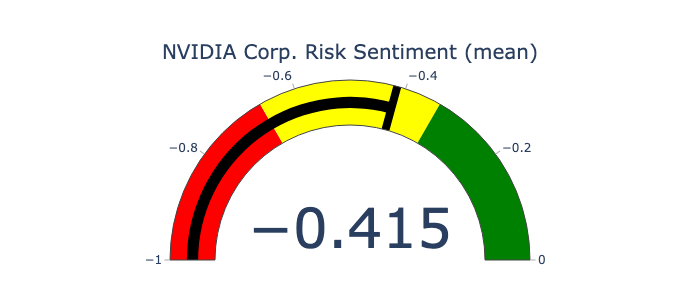

2026-08-28 11:12:09,312 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:09,313 - INFO - shutil.rmtree worked.


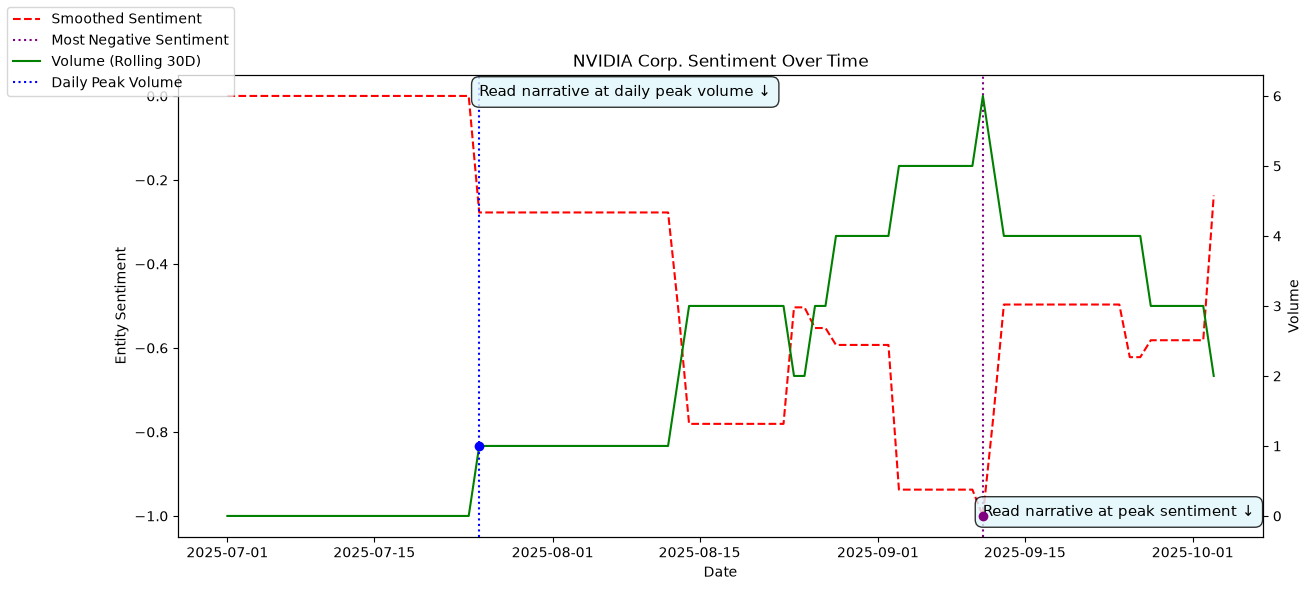

## Peak Volume Narrative - Date: 25-07-2025

NVIDIA Corp. is receiving negative coverage primarily because its market valuation is viewed as a potential indicator of AI and technology-market bubble conditions, with the 25 July 2025 headline “It’s fear, not greed, that drives the stock market” noting that Nvidia’s market capitalisation had exceeded $4 trillion amid “furious buying” of US technology stocks. The reported risks are indirect but relevant to refinancing: excess liquidity, herd-driven borrowing, speculative investment and the use of volatile assets as collateral could abruptly tighten financing conditions or reduce lenders’ tolerance for highly valued growth companies if sentiment reverses. The underlying drivers are intense optimism about AI, abundant liquidity and momentum-based purchasing rather than demonstrated fundamentals, with the article describing “incipient bubble euphoria” and warning that excessive risk-taking can accelerate market-wide instability. A sharp correction in Nvidia’s share price could increase perceived credit and counterparty risk, raise the cost of capital, weaken access to debt or equity refinancing, and expose stakeholders to losses, although the extract provides no evidence of current refinancing stress, excessive leverage or real-estate exposure at Nvidia itself. The key actionable signal is therefore valuation and sentiment monitoring: sustained dependence on optimistic AI expectations, concentrated investor positioning or deteriorating market liquidity would indicate rising indirect refinancing risk, while the company’s cash generation, debt maturities and funding diversification would determine its ability to withstand a broader technology-market correction.

## Most Negative Sentiment Narrative - Date: 11-09-2025

NVIDIA is receiving negative coverage on real-estate refinancing risk because the AI infrastructure boom increasingly relies on highly leveraged data-centre construction and loans secured by NVIDIA GPUs, creating indirect exposure to collateral devaluation, refinancing stress and a potential pullback in chip demand. The 14 August 2025 article, “Who pays for the $3tn AI building boom?”, highlights high loan-to-value financing, concern that data centres and their equipment could become obsolete before debt matures, and warns that overleveraged operators are more vulnerable than cash-rich hyperscalers; rapid transitions from current Blackwell systems to faster chips or new cooling requirements could leave lenders with impaired security and borrowers unable to refinance on acceptable terms. The 13 August coverage similarly describes unusual AI financing structures and “nosebleed valuations,” raising the prospect of a correction that could reduce capital availability for NVIDIA-dependent infrastructure customers. This risk is compounded by rising yields and broader bond-market concerns cited on 3 September, which could increase borrowing costs and pressure high-valuation technology assets. Competitive and demand uncertainty is also emerging: on 26 August Truist reported that hyperscalers were showing growing interest in deploying AMD at scale, while an 28 August industry discussion emphasized that cloud customers cannot yet predict whether workloads will require NVIDIA or AMD capacity. A severe correction could therefore weaken data-centre counterparties, reduce the value of GPU-backed collateral, delay infrastructure orders and expose NVIDIA to a sharper-than-expected slowdown despite its strong current position. The risk is partly mitigated by hyperscalers’ scale and by equity-funded, lease-backed development such as DigitalBridge’s projects discussed on 11 September, but the coverage indicates that refinancing risk is concentrated among highly leveraged operators and remains elevated as AI economics, technology lifecycles and long-term capacity demand have yet to be proven.

2026-08-28 11:12:09,448 - INFO - Chromium init'ed with kwargs {}


...

2026-08-28 11:12:11,536 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:11,679 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:11,680 - INFO - shutil.rmtree worked.


2026-08-28 11:12:11,680 - INFO - Cancelling tasks.


2026-08-28 11:12:11,681 - INFO - Exiting Kaleido/Choreo.


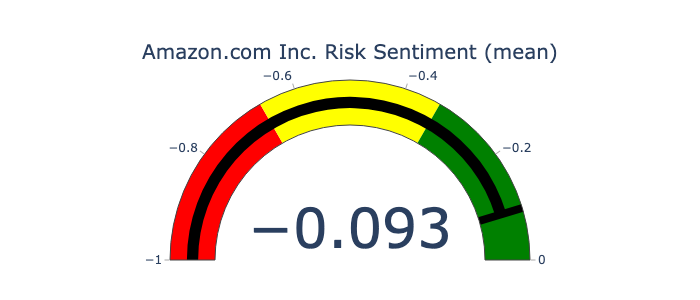

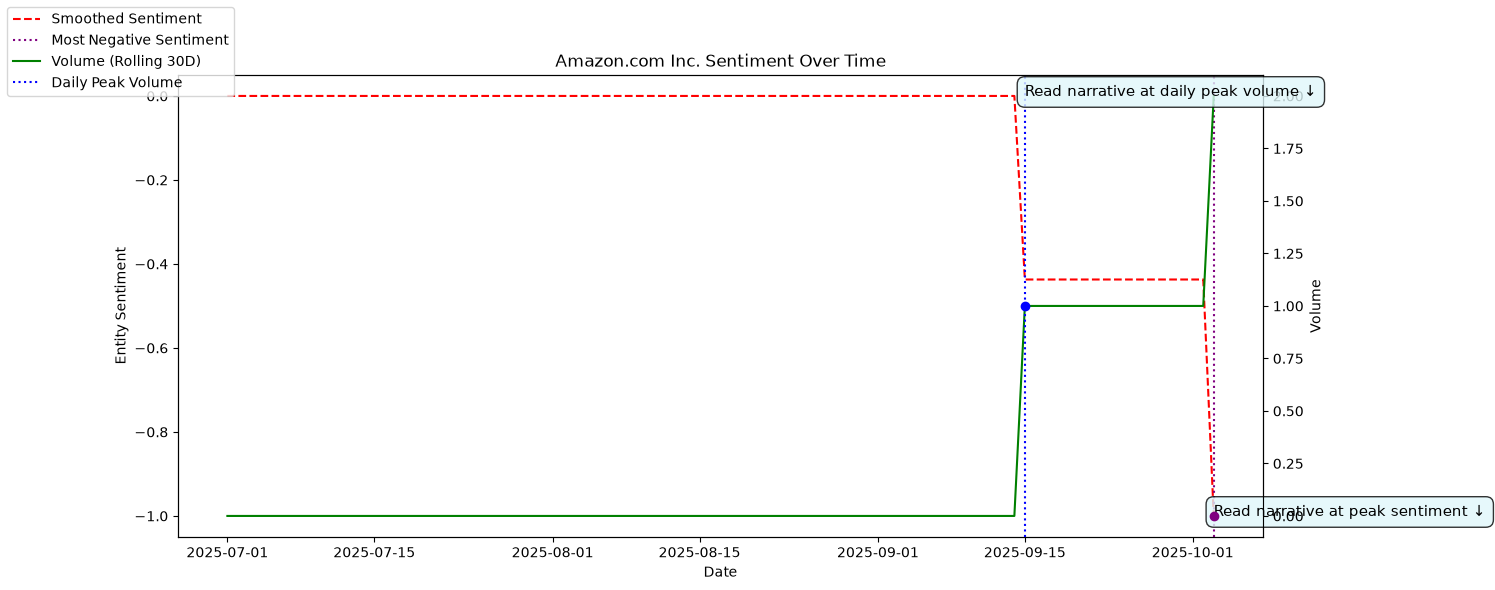

## Peak Volume Narrative - Date: 15-09-2025

The 15 September 2025 coverage in “LONDON MARKET MIDDAY: FTSE 100 struggles but pound tops USD1.36” does not identify a material real-estate refinancing risk for Amazon.com Inc. Amazon is mentioned only as a major technology-sector client of S4 Capital, which reported longer sales cycles, cautious client spending, and a mid-single-digit 2025 revenue decline amid volatile macroeconomic conditions and tariff uncertainty; S4 Capital nevertheless expects improved second-half revenue partly from business involving Amazon. The relevant indirect signal is that technology companies are prioritising capital expenditure on AI capacity, potentially affecting advertising and technology-service suppliers, but the extract provides no evidence of Amazon’s debt maturities, property exposure, liquidity constraints, refinancing difficulty, or adverse real-estate consequences. Accordingly, any risk to Amazon inferred from this item is low and limited to broader corporate-spending and supplier-demand uncertainty rather than a substantiated refinancing risk in real estate.

## Most Negative Sentiment Narrative - Date: 03-10-2025

Amazon.com Inc. is not directly implicated in the supplied coverage as facing real-estate refinancing risk; the 15 September 2025 London market report mentions Amazon only as a prospective client supporting S4 Capital’s hoped-for second-half recovery, while S4’s downgrade reflects “continued wider market uncertainty,” cautious technology customers, tariff negotiations and longer sales cycles. The 3 October 2025 Kurv ETF filing instead identifies broader financial and sector risks for Amazon, including fluctuating results, foreign-exchange exposure, credit risk on receivables and supply-related prepayments during weaker economic conditions, investment-portfolio volatility, tax changes and intense technology-sector competition. These risks are potentially material because macroeconomic weakness or reduced technology spending could pressure counterparties, vendors and cash generation, but the extracts provide no evidence of Amazon’s property debt maturities, refinancing needs, covenant pressure or exposure to distressed real-estate assets. The actionable conclusion is therefore that refinancing-related real-estate risk is unsubstantiated in this dataset; monitoring should focus instead on technology-capacity investment cycles, customer demand, liquidity and credit conditions, alongside any future disclosures on debt structure, property obligations or interest-rate sensitivity.

2026-08-28 11:12:11,791 - INFO - TemporaryDirectory.cleanup() worked.


...

2026-08-28 11:12:13,822 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:13,917 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:13,918 - INFO - shutil.rmtree worked.


2026-08-28 11:12:13,918 - INFO - Cancelling tasks.


2026-08-28 11:12:13,918 - INFO - Exiting Kaleido/Choreo.


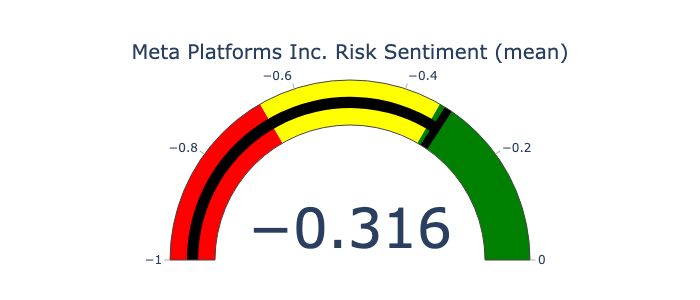

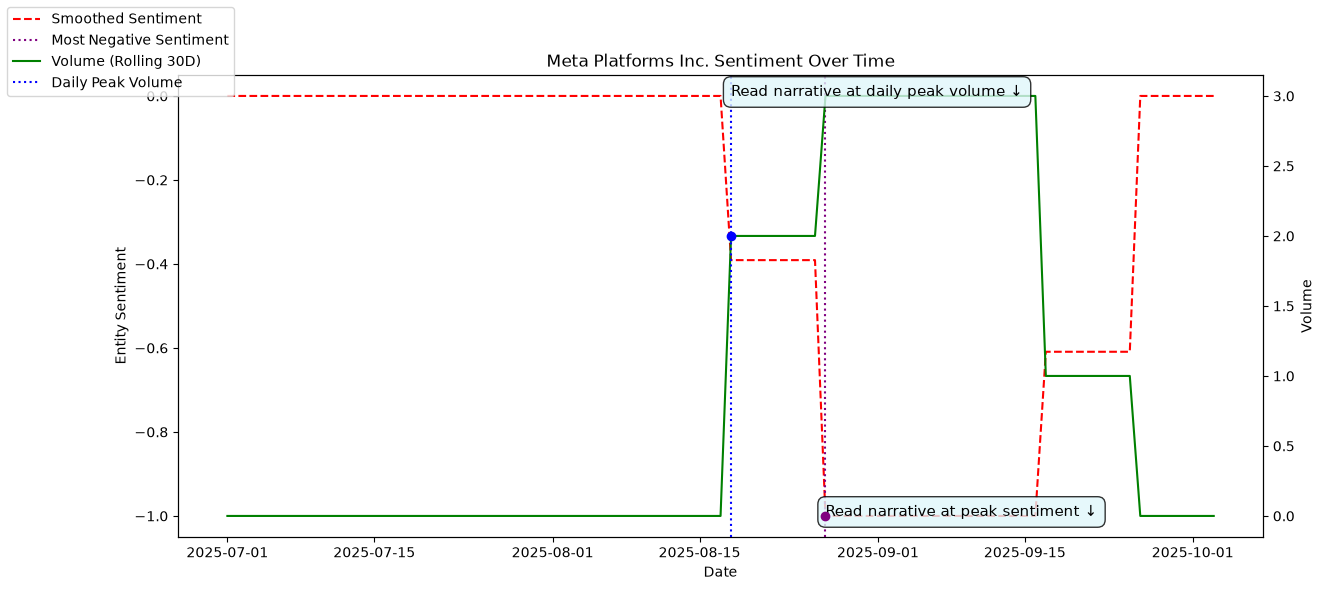

## Peak Volume Narrative - Date: 18-08-2025

Meta Platforms Inc. is receiving negative coverage dated August 18, 2025, but the cited material does not identify a direct real-estate refinancing risk; rather, it highlights broader regulatory, AI-investment, and market-valuation vulnerabilities that could indirectly affect financing conditions. The headline “As Meta Faces AI Scrutiny, Mounting Regulatory Risk Overshadows Strong Earnings And Pushes Stock Lower” points to controversy over AI bias, including a settled lawsuit alleging that Meta’s AI falsely linked activist Robby Starbuck to the January 6 Capitol riot, followed by his appointment as an adviser on political bias—an action that has intensified reputational and governance concerns. These issues are significant because regulatory action, litigation, operational upheaval, or weakened investor confidence could raise Meta’s cost of capital and reduce financial flexibility, although strong earnings growth—reported at roughly three times the S&P 500’s pace—provides an important mitigating factor. The accompanying “Tech utterly dominates markets. Should we worry?” coverage adds concentration and capital-allocation risk: Microsoft, Amazon, Alphabet, and Meta together spent $291 billion on capital expenditure in the prior year, creating uncertainty over whether intense AI competition will generate adequate returns. A slowdown in technology-sector growth, disappointing AI profitability, or a broad economic contraction could compress Meta’s premium valuation and potentially impair access to attractive refinancing, even if operating profits remain resilient. The actionable signal is that Meta’s immediate risk is primarily sentiment, regulatory, and AI-return related rather than property-financing specific; investors and creditors should monitor regulatory developments, AI spending efficiency, valuation compression, and liquidity resilience as leading indicators of any future refinancing pressure.

## Most Negative Sentiment Narrative - Date: 27-08-2025

Meta Platforms Inc. is receiving negative coverage because its AI expansion is creating substantial financing and asset-investment risk alongside regulatory and reputational pressures. On August 27, 2025, reports that the Hyperion data-center project could cost as much as $50 billion—after an earlier reported $29 billion financing package led by Blue Owl Capital and Pacific Investment Management Co.—raised concerns that Meta’s AI infrastructure build-out is becoming an unusually large, real-estate-intensive capital commitment rather than ordinary technology spending. The scale increases refinancing and credit-spread risk: if AI returns disappoint, competition limits monetization, or market conditions weaken, Meta could face higher funding costs, pressure to refinance project-related debt or financing structures, and underutilized data-center assets with impaired returns. This concern is reinforced by broader warnings that major technology companies have collectively invested $291 billion in capital expenditure, potentially exposing investors to low returns and valuation compression during an economic slowdown. Although Meta’s earnings growth is reportedly strong—around three times the S&P 500’s pace—the August 18 coverage indicates that regulatory threats, AI-bias controversies, and costly strategic execution are already weighing on sentiment. The principal risk is therefore not immediate solvency but escalating capital intensity, uncertain AI cash-flow generation, and the possibility that a premium-valued company must continue funding or refinancing large infrastructure projects before their economic benefits are proven; shareholders should monitor project financing terms, debt levels, construction commitments, data-center utilization, AI revenue growth, and management’s ability to scale spending without weakening credit quality.

2026-08-28 11:12:14,014 - INFO - Chromium init'ed with kwargs {}


...

2026-08-28 11:12:16,025 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:16,113 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:16,113 - INFO - shutil.rmtree worked.


2026-08-28 11:12:16,114 - INFO - Cancelling tasks.


2026-08-28 11:12:16,114 - INFO - Exiting Kaleido/Choreo.


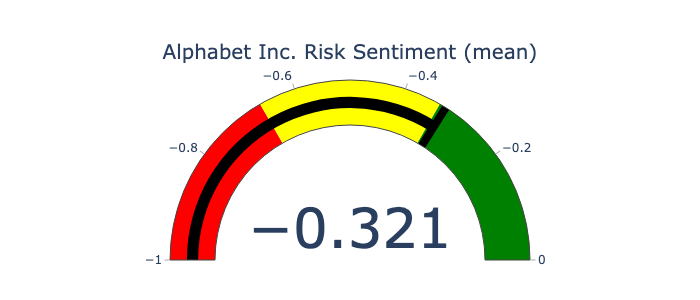

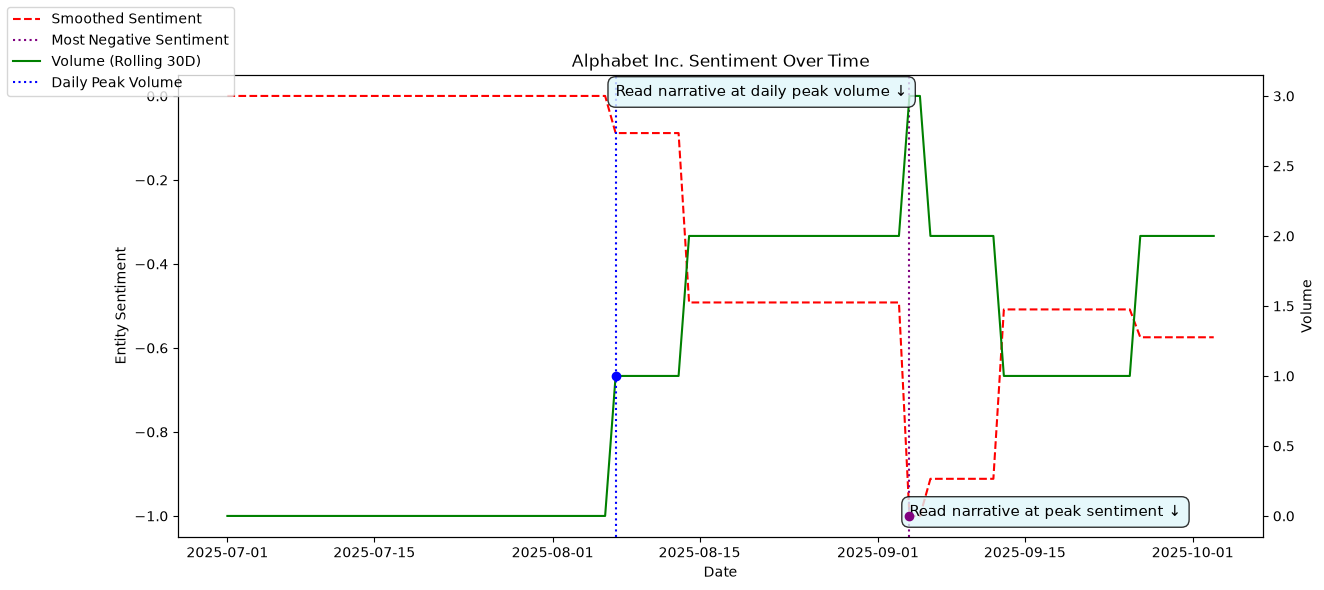

## Peak Volume Narrative - Date: 07-08-2025

Alphabet Inc. is receiving indirect negative coverage related to real-estate refinancing risk through the capital-intensive expansion of hyperscale data-center infrastructure. In the 7 August 2025 DigitalBridge Group Q2 earnings call, management identified power as “the most critical bottleneck in the entire ecosystem” and described investments in platforms designed to solve this constraint for hyperscalers, including Google; the reference to an ex-Google and Microsoft energy team underscores Alphabet’s exposure to the broader race for data-center capacity. Although the extract does not cite Alphabet debt maturities, refinancing activity, or a company-specific funding shortfall, it signals elevated execution and financing risk: securing powered sites, constructing facilities, and scaling capacity require substantial long-term capital, while constrained power availability can delay projects, increase costs, and weaken asset economics. In a market where investment managers are aggressively pursuing power and data centers, competition for infrastructure and financing may raise funding costs and intensify dependence on external partners such as DigitalBridge. The principal consequence for Alphabet is potential pressure on returns, deployment timelines, and future borrowing or refinancing needs if expansion outpaces cash generation; investors should therefore monitor capital commitments, data-center lease or ownership structures, power procurement, project delays, and any change in credit conditions.

## Most Negative Sentiment Narrative - Date: 04-09-2025

Alphabet Inc. is receiving negative coverage relevant to real-estate refinancing risk because its position as a major hyperscaler links it to the exceptionally capital-intensive expansion of AI data centers. On August 14, 2025, “Who pays for the $3tn AI building boom?” reported that Google, Amazon, Microsoft and Meta are expected to spend more than $400 billion on data centers in 2026, following over $350 billion in 2025, while questioning whether internal cash flows can sustain the investment and when AI revenues will justify it; generative-AI revenue was estimated at only $45 billion in 2024 despite forecasts of more than $1 trillion by 2028. Although the article does not identify an immediate Alphabet refinancing failure, the scale and acceleration of spending could increase reliance on external debt, joint ventures, or infrastructure financing, exposing Alphabet and its landlords, lenders and development partners to refinancing pressure if interest rates remain high, cash returns lag, or data-center utilization disappoints. The principal risks are overcapacity, power constraints, escalating construction and operating costs, and declining asset values if capital markets become less willing to fund speculative projects; a banker’s warning that “lots of people who are trying to build data centres will fail” underscores the severity of the sector-wide funding risk. DigitalBridge’s August 7 earnings call further illustrates the competitive scramble for power and hyperscaler-oriented infrastructure, describing power as the “most critical bottleneck,” which may raise Alphabet’s occupancy costs and delay capacity delivery. The September 4 short report on Pure Storage adds an indirect demand and technology risk, arguing that hyperscalers may reject premium storage solutions because hard drives retain a 5–6x cost advantage for bulk storage, potentially encouraging tighter procurement and reducing returns on AI infrastructure. Overall, Alphabet’s strong cash generation provides greater resilience than smaller developers, but the coverage signals a rising need to match data-center commitments with contracted demand, phased investment and visible AI monetization; otherwise, sector repricing could raise refinancing costs, impair infrastructure assets and pressure suppliers and financing counterparties.

2026-08-28 11:12:16,216 - INFO - Chromium init'ed with kwargs {}


...

2026-08-28 11:12:18,141 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:18,290 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:18,290 - INFO - shutil.rmtree worked.


2026-08-28 11:12:18,291 - INFO - Cancelling tasks.


2026-08-28 11:12:18,291 - INFO - Exiting Kaleido/Choreo.


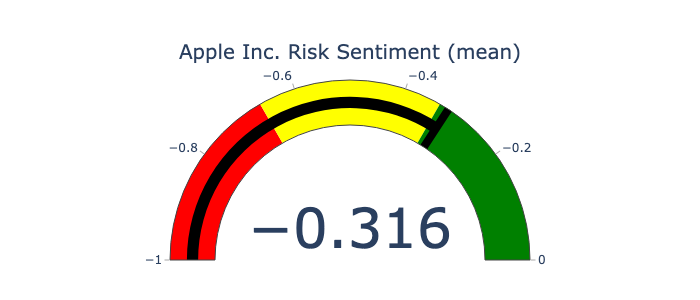

2026-08-28 11:12:18,295 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:18,295 - INFO - shutil.rmtree worked.


2026-08-28 11:12:18,311 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:18,311 - INFO - shutil.rmtree worked.


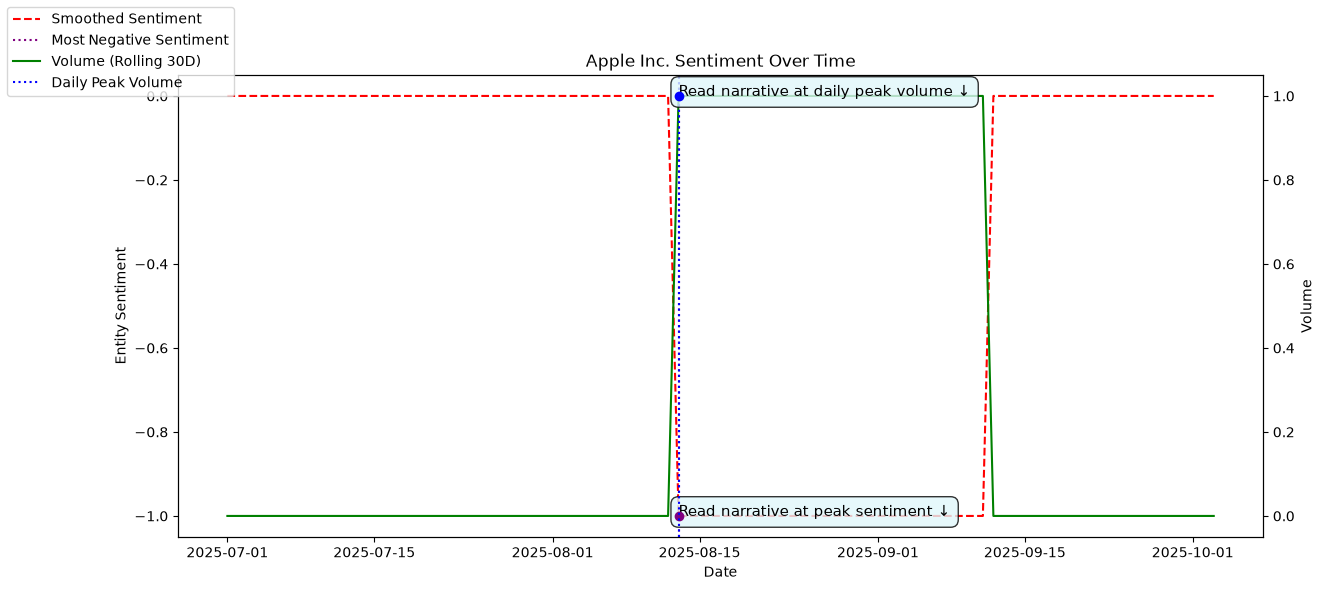

## Peak Volume Narrative - Date: 13-08-2025

Apple Inc. is receiving negative indirect coverage on refinancing risk because the August 13, 2025 report, “US National Debt Hits Historic $37 Trillion, Surpassing Pre-Pandemic Projections—‘Piling Up At A Rapid Rate,’ Warn Economists,” describes a deteriorating U.S. fiscal and interest-rate environment rather than an Apple-specific real-estate exposure. The Government Accountability Office and Peter G. Peterson Foundation warn that debt is accumulating at an accelerated pace, while higher government borrowing may raise economy-wide financing costs, suppress wages, and increase prices; the IMF and Ray Dalio likewise caution that extended tax cuts and widening deficits could produce more severe repercussions. For Apple, whose global operations depend on leased offices, retail locations, logistics facilities, and other property-related commitments, persistently higher rates could increase the cost of refinancing leases, facilities, or associated corporate debt and reduce asset values or consumer purchasing power, although the extract provides no evidence of current covenant stress, missed payments, or material property losses. The immediate risk is therefore moderate and primarily macroeconomic: sustained fiscal pressure could keep funding costs elevated, constrain investment returns, and weaken demand for discretionary technology products, while Apple’s scale and financial strength may provide greater resilience than more highly leveraged real-estate-dependent peers. The key actionable signal is to monitor U.S. Treasury yields, corporate credit spreads, lease and property-financing costs, and Apple’s liquidity and maturity disclosures; the accelerating debt trajectory raises the medium-term refinancing risk outlook but does not establish an acute entity-specific crisis.

## Most Negative Sentiment Narrative - Date: 13-08-2025

Apple Inc. is receiving negative coverage for an indirect but potentially material refinancing risk arising from deteriorating U.S. fiscal conditions rather than from a reported property-specific financing problem. The August 13, 2025 headline, “US National Debt Hits Historic $37 Trillion,” reports that debt is increasing by $1 trillion approximately every five months, while the Government Accountability Office warns that higher public borrowing is pushing up financing costs, suppressing wages, and increasing prices. For Apple, sustained fiscal deficits, inflationary pressure, and the possibility of higher-for-longer interest rates could raise the cost of refinancing corporate debt and any real-estate-related obligations, reduce consumer purchasing power, and weaken demand for discretionary products. The risk is currently indirect and moderate, but its severity would increase if debt-driven market volatility or sovereign risk repricing caused credit spreads to widen, especially as the IMF and Ray Dalio warn of broader economic repercussions. The key actionable signal is to monitor Apple’s debt maturities, interest-rate exposure, liquidity, and commercial-property commitments alongside U.S. Treasury yields and credit spreads; absent evidence of refinancing stress in Apple’s disclosures, the coverage indicates a macroeconomic vulnerability rather than an immediate entity-specific default concern.

2026-08-28 11:12:18,391 - INFO - Chromium init'ed with kwargs {}


...

2026-08-28 11:12:20,381 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:20,531 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:20,531 - INFO - shutil.rmtree worked.


2026-08-28 11:12:20,531 - INFO - Cancelling tasks.


2026-08-28 11:12:20,532 - INFO - Exiting Kaleido/Choreo.


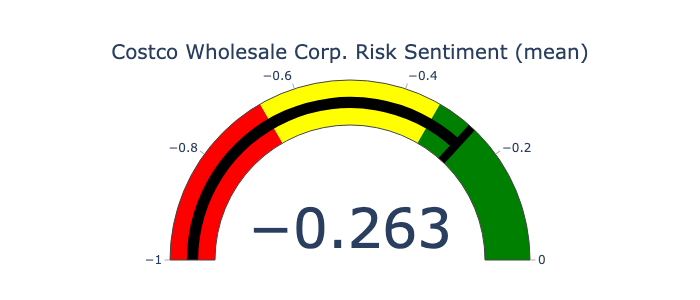

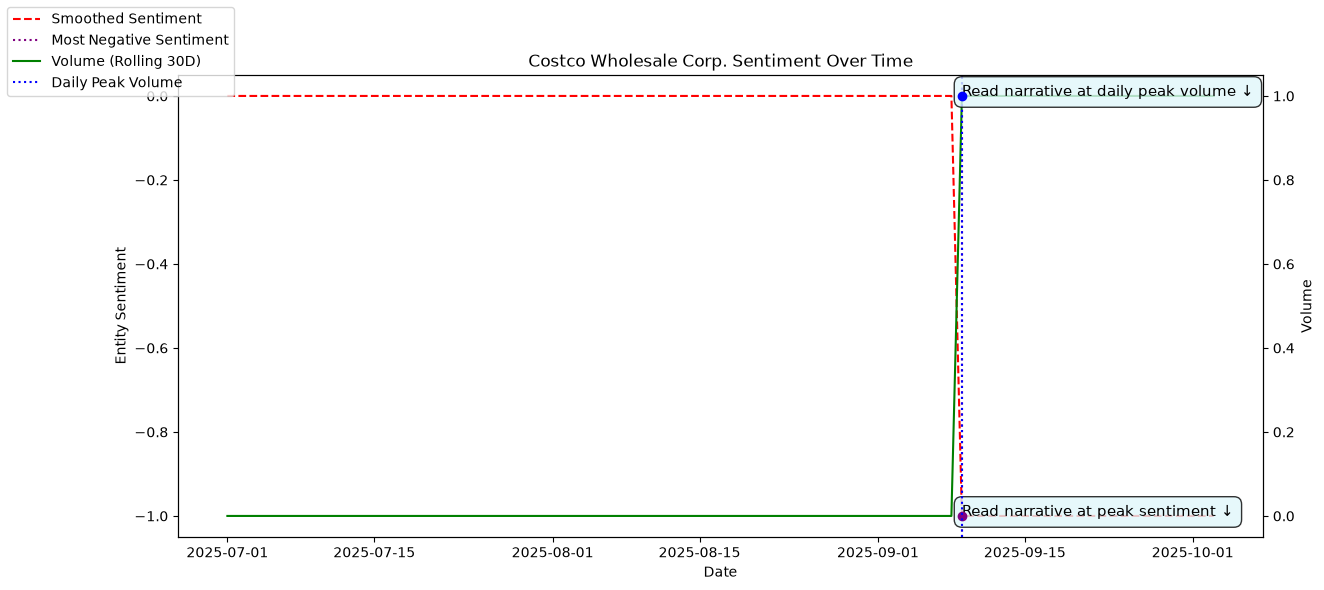

## Peak Volume Narrative - Date: 09-09-2025

Costco Wholesale Corp. received coverage on September 9, 2025, in the article “Does valuation matter any more in the age of AI?”, but the discussion concerns equity valuation and AI resilience rather than real-estate refinancing risk. Costco is presented as a relatively robust, membership-based retailer whose improving margin outlook drove its shares to more than 50 times forward earnings at the prior year’s peak, implying elevated valuation and sensitivity to any disappointment in earnings, margins, or membership growth. The article’s broader message is that businesses perceived as resistant to AI disruption may continue to command expanding multiples, while companies exposed to AI-driven business-model pressure face declining growth expectations and valuation compression, as illustrated by Getty Images. No information is provided on Costco’s property debt maturities, refinancing needs, interest coverage, lender conditions, or real-estate exposure; consequently, the extract does not establish a refinancing risk or indicate a change in that risk. The actionable signal is instead to monitor whether Costco can sustain margin expansion and justify its premium valuation as interest rates, consumer conditions, and AI-related market sentiment evolve.

## Most Negative Sentiment Narrative - Date: 09-09-2025

Costco Wholesale Corp. receives no material negative coverage related to real-estate refinancing risk in the 9 September 2025 extract, which instead examines whether valuation remains relevant in the age of AI. The article notes that Costco’s share price traded at more than 50 times forward earnings as confidence in improving margins strengthened, suggesting elevated valuation and potential sensitivity to any disappointment in earnings, margins, or long-term growth expectations. However, it presents Costco’s membership-based retail model as relatively resilient to AI disruption rather than identifying property debt, refinancing needs, interest-rate exposure, or real-estate liquidity concerns. Accordingly, the relevant signal is valuation risk—not refinancing risk—with the principal consequence being possible share-price compression if projected margin expansion or durable growth fails to materialize; no specific refinancing trigger, severity assessment, or stakeholder impact is provided.

2026-08-28 11:12:20,637 - INFO - Chromium init'ed with kwargs {}


...

2026-08-28 11:12:22,644 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:22,839 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:22,840 - INFO - shutil.rmtree worked.


2026-08-28 11:12:22,840 - INFO - Cancelling tasks.


2026-08-28 11:12:22,840 - INFO - Exiting Kaleido/Choreo.


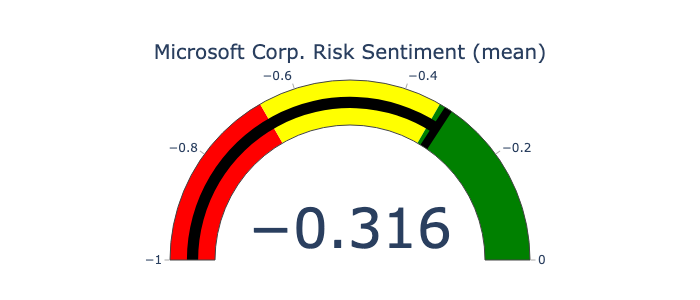

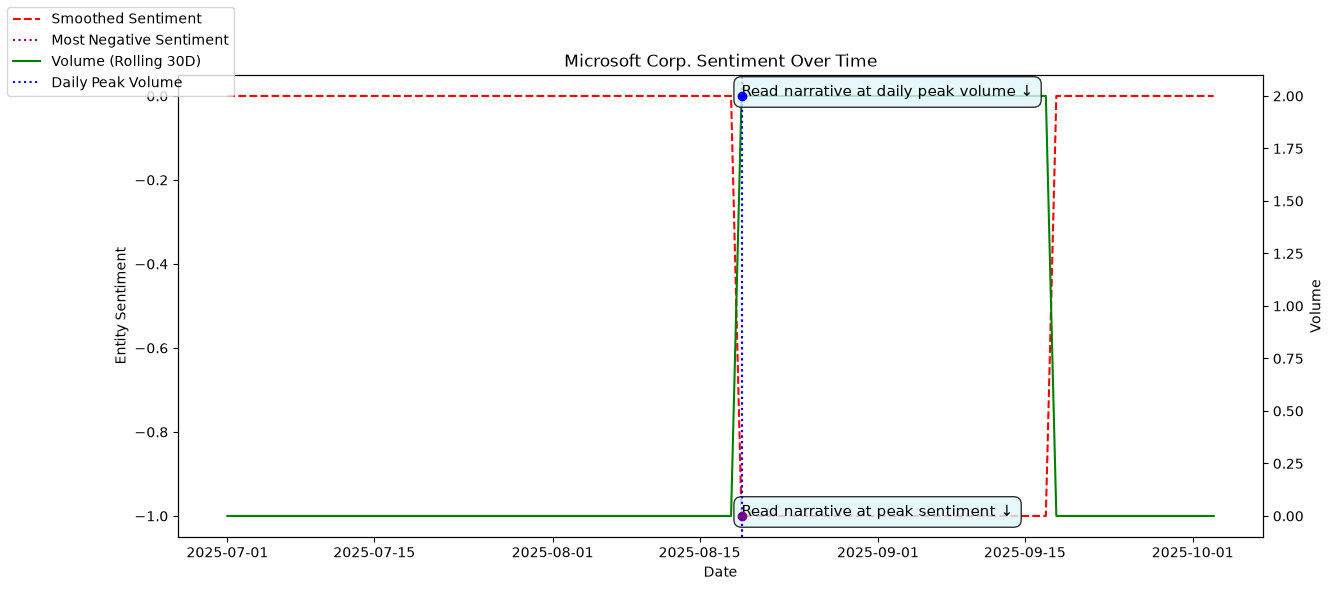

## Peak Volume Narrative - Date: 19-08-2025

Microsoft is receiving negative coverage primarily through indirect exposure to refinancing risk in the data-center real-estate sector, rather than from a disclosed Microsoft refinancing problem. In the 19 August 2025 Infratil shareholder and analyst discussions, CDC was described as serving only around 120–130 customers, with significant concentration among the four large Western hyperscalers—including Microsoft—and government clients. This concentration supports occupancy and revenue visibility but creates counterparty and leverage concerns: hyperscalers could eventually build or shift capacity in-house, potentially weakening data-center landlords’ cash flows, asset valuations, and ability to refinance construction or expansion debt. CDC argued that government security requirements, interconnection benefits, and Australian legal requirements make customer relationships “sticky,” yet the shareholder question about customers leaving after ten years highlights the underlying durability risk. For Microsoft, the implication is indirect but relevant: its scale and bargaining power make it a strategically important tenant and can contribute to dependence on a small group of hyperscalers across specialist real-estate portfolios; any reduction in outsourced capacity, slower cloud demand, or reprioritization of capital spending could increase refinancing pressure for operators and affect the availability or economics of future capacity. The immediate severity appears moderate rather than acute, as the coverage emphasizes customer retention and regulatory barriers rather than missed payments or liquidity stress, but concentration and long-dated data-center investment remain warning signals requiring monitoring of Microsoft’s leasing and capacity strategy, CDC’s debt maturities, occupancy commitments, and broader hyperscaler demand.

## Most Negative Sentiment Narrative - Date: 19-08-2025

Microsoft is referenced in 19 August 2025 coverage of Infratil’s CDC data-center business as one of four major Western hyperscalers whose demand supports the sector, creating an indirect real-estate refinancing risk rather than evidence of a Microsoft-specific funding problem. CDC’s concentrated customer base of approximately 120–130 government and hyperscale-related clients means that Microsoft and its peers have significant commercial influence over occupancy, contract terms, expansion decisions, and the cash flows used by data-center owners to service and refinance property debt. Management argues that government security requirements, Australia’s co-location rules, and customer interconnection within facilities make this revenue relatively sticky, but shareholder concerns that hyperscalers could ultimately build or shift capacity highlight a material concentration and bargaining-power risk. If Microsoft or other large customers reduced commitments, delayed deployments, or imposed pricing pressure, affected data centers could face lower valuations, weaker debt-service coverage, and more difficult or expensive refinancing, particularly amid high capital requirements and tight credit conditions for infrastructure real estate. The immediate severity is moderate and primarily structural, as the transcript provides no indication of an actual Microsoft withdrawal; however, the reliance on a small group of powerful hyperscalers makes customer retention, contract duration, renewal terms, and tenant-funded expansion key indicators for monitoring refinancing vulnerability.

In [24]:
gauge_value = "mean"                                    # Options: "min", "mean"
sentiment_col_to_use = "Sent_Rolling_30Days_Normalized" # Options: "Sent_Rolling_30Days" or "Sent_Rolling_30Days_Normalized"

if not ranked_countries.empty:
    for entity in ranked_countries.index:
        display_dashboard(
            daily_sentiment,
            entity,
            sentiment_col_to_use,
            narratives=entity_narratives,
            volume_type="rolling",
            export_mode=True,
            gauge_value=gauge_value,
        )
else:
    print("No ranked entities available -- skipping per-entity dashboards.")


Creates comparative visualizations of risk scores across countries, showing aggregated exposure to different risk channels identified in the thematic analysis.


2026-08-28 11:12:23,029 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:23,030 - INFO - shutil.rmtree worked.


2026-08-28 11:12:23,030 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:23,030 - INFO - shutil.rmtree worked.


2026-08-28 11:12:23,046 - INFO - Chromium init'ed with kwargs {}


...

2026-08-28 11:12:25,022 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:25,114 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:25,115 - INFO - shutil.rmtree worked.


2026-08-28 11:12:25,115 - INFO - Cancelling tasks.


2026-08-28 11:12:25,115 - INFO - Exiting Kaleido/Choreo.


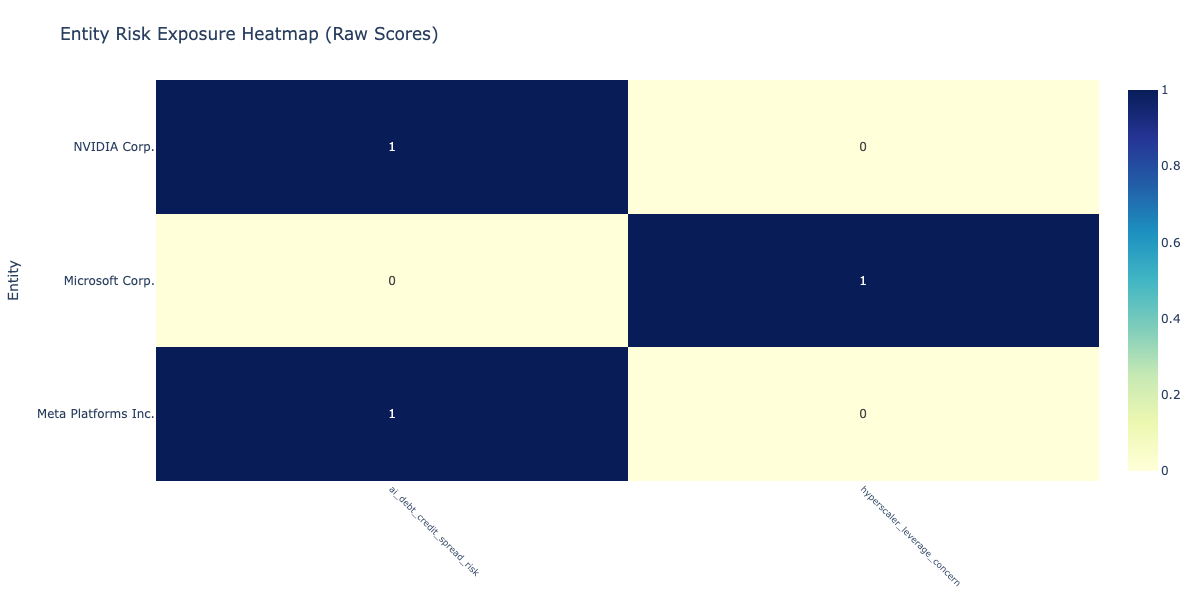

2026-08-28 11:12:25,118 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:25,118 - INFO - shutil.rmtree worked.


2026-08-28 11:12:25,119 - INFO - Chromium init'ed with kwargs {}


2026-08-28 11:12:25,121 - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


2026-08-28 11:12:25,122 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmpu2s1xmgc.


...

2026-08-28 11:12:27,103 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:27,247 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:27,248 - INFO - shutil.rmtree worked.


2026-08-28 11:12:27,248 - INFO - Cancelling tasks.


2026-08-28 11:12:27,248 - INFO - Exiting Kaleido/Choreo.


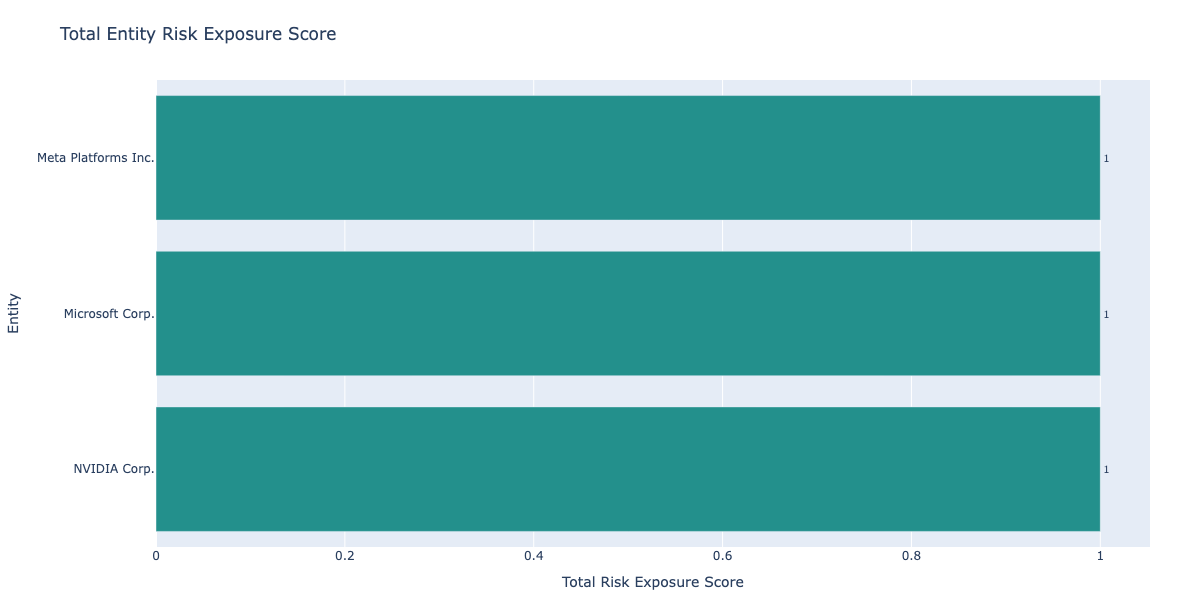

2026-08-28 11:12:27,252 - INFO - Chromium init'ed with kwargs {}


2026-08-28 11:12:27,253 - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


2026-08-28 11:12:27,254 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmpz53vda8p.


2026-08-28 11:12:27,254 - INFO - Opening browser.


2026-08-28 11:12:27,255 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmp1ialwpw6.


...

2026-08-28 11:12:29,201 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:29,350 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:29,350 - INFO - shutil.rmtree worked.


2026-08-28 11:12:29,351 - INFO - Cancelling tasks.


2026-08-28 11:12:29,351 - INFO - Exiting Kaleido/Choreo.


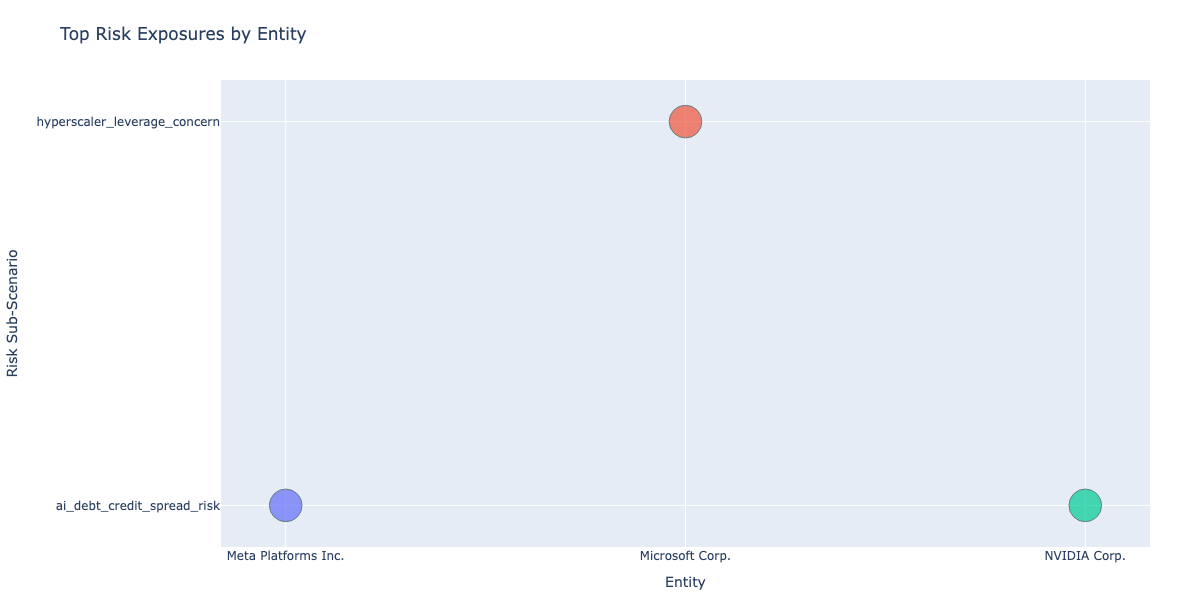

2026-08-28 11:12:29,354 - INFO - Chromium init'ed with kwargs {}


2026-08-28 11:12:29,356 - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


2026-08-28 11:12:29,356 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmpq6f4o4v5.


2026-08-28 11:12:29,356 - INFO - Opening browser.


2026-08-28 11:12:29,357 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmpce3tzfij.


...

2026-08-28 11:12:31,131 - INFO - Exiting Kaleido/Choreo.


2026-08-28 11:12:31,273 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-28 11:12:31,274 - INFO - shutil.rmtree worked.


2026-08-28 11:12:31,274 - INFO - Cancelling tasks.


2026-08-28 11:12:31,274 - INFO - Exiting Kaleido/Choreo.


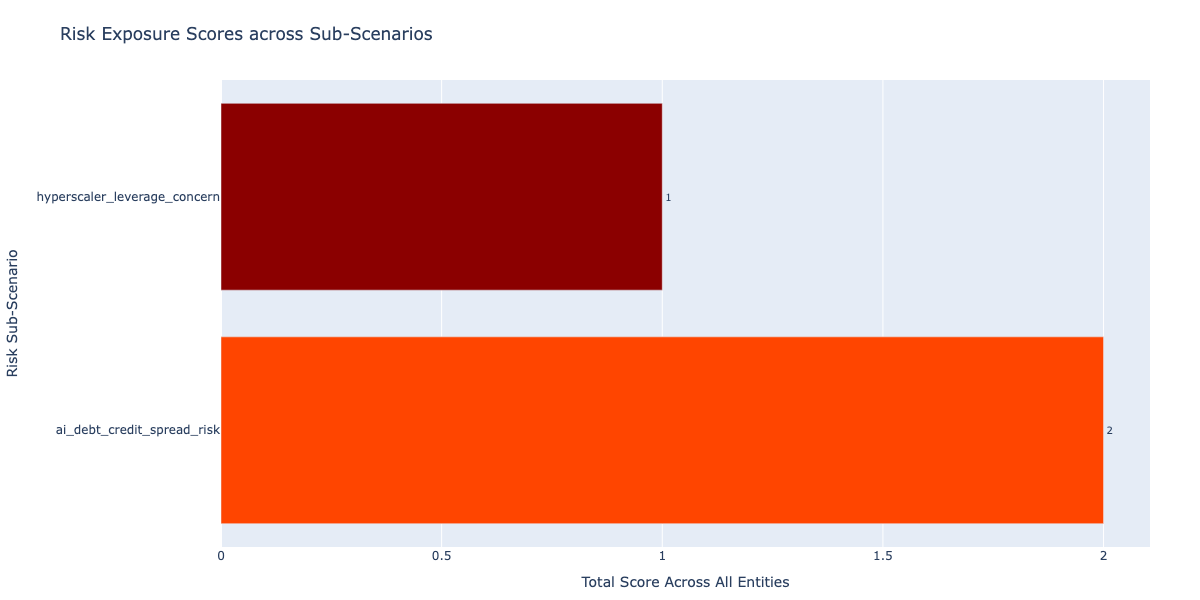

In [25]:
if not df_entity.empty:
    display_risk_figures_cookbooks(df_entity, interactive=True, n_entities=10)
else:
    print("No composite score data -- skipping risk exposure charts.")


## Export Results to CSV Files

Saves all generated datasets (labeled results, risk scores, daily indicators, country rankings) to CSV files in the output folder for further analysis or reporting.


In [26]:
try:
    df_labels.to_csv(f"{output_dir}/labeled_search_results.csv", index=False)
    df_entity.to_csv(f"{output_dir}/entity_risk_scores.csv")
    daily_sentiment.to_csv(f"{output_dir}/daily_sentiment_indicators.csv")
    ranked_countries.to_csv(f"{output_dir}/peak_coverage_analysis.csv")
    df_search_raw.to_csv(f"{output_dir}/raw_search_results.csv", index=False)
    print(f"✅ Exported results to {output_dir}")
except Exception as e:
    print(f"❌ Export error: {e}")


✅ Exported results to output
